In [1]:
#Load modules
import pandas as pd
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [2]:
#Exercise 1(a)

#pre-process the data
df = pd.read_csv("insurance.csv")
df.head()

y= df['charges']
X = df.drop('charges',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) 

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe


In [3]:
#Exercise 1(b)
#Make the prediction
regressor = RandomForestRegressor(n_estimators=100, random_state=69) #create a forest with 100 trees
RFscores = cross_val_score(regressor, X, y, cv=5,
                           scoring='neg_mean_absolute_error')
MAE = mean(absolute(RFscores))
print ('the MAE is: %.2f' % MAE)

the MAE is: 2702.86


In [4]:
#Exercise 1(c)
#Get the most important features
regressor.fit(X,y) #Fit the data to the random forest model
feature_importances = regressor.feature_importances_ #get the GINI importances

importance_df = pd.DataFrame({ #create a dataframe shat shows the importance for each feature
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False) #sort the data from high to low

print(importance_df) #print the result

            Feature  Importance
5        smoker_yes    0.621275
1               bmi    0.206497
0               age    0.127838
2          children    0.018443
6  region_northwest    0.005964
4          sex_male    0.005669
3             death    0.005314
7  region_southeast    0.004957
8  region_southwest    0.004042


In [5]:
#Exercise 2(a)
#pre-process the data
df = pd.read_csv("insurance.csv")

#select features
y= df['death']
X = df.drop('death',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) 

#Normalize the data
columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

In [6]:
#Exercise 2(b)
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Define the model and hyperparameter search
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 250, step=10),  # number of trees
        'max_depth': trial.suggest_int('max_depth', 10, 250, step=10),
        'min_samples_split': trial.suggest_int('min_samples_split', 10, 30, step=1),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'random_state': 69
    }
    rf = RandomForestClassifier(**params)
    score = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1).mean()
    return score

# search across 100 different combinations
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=69))
study.optimize(objective, n_trials=100, n_jobs=-1)

study.best_params  # reveal the best hyperparameters

c:\MINORDM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-10-02 13:15:25,345] A new study created in memory with name: no-name-05f45dc1-56fa-42bf-b1f4-0126cbe0643c
[I 2026-10-02 13:15:31,567] Trial 2 finished with value: 0.8400581362848678 and parameters: {'n_estimators': 50, 'max_depth': 240, 'min_samples_split': 10, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.8400581362848678.
[I 2026-10-02 13:15:31,735] Trial 3 finished with value: 0.8340963720722231 and parameters: {'n_estimators': 160, 'max_depth': 140, 'min_samples_split': 28, 'max_features': None}. Best is trial 2 with value: 0.8400581362848678.
[I 2026-10-02 13:15:31,776] Trial 1 finished with value: 0.8445609033484265 and parameters: {'n_estimators': 60, 'max_depth': 200, 'min_samples_split': 30, 'max_features': 'sqrt'}. Best is 

{'n_estimators': 90,
 'max_depth': 140,
 'min_samples_split': 30,
 'max_features': 'sqrt'}

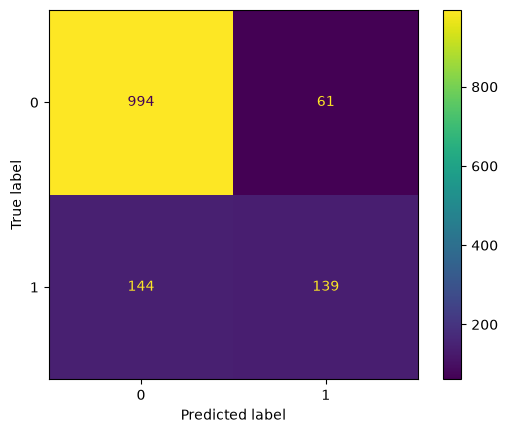

Accuracy: 0.8467862481315396


In [7]:
#Exercise 2(c)
#Create optimal prediction
rf = RandomForestClassifier(**study.best_params,
                            random_state=69)

y_pred = cross_val_predict(rf, X, y, cv=5) #make the predictions

cm = confusion_matrix(y, y_pred) #create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #create the graph
disp.plot() #plot the graph
plt.show() #show the graph

accuracy = (cm.diagonal().sum()) / cm.sum() #calculate accuracy
print("Accuracy:",accuracy) #print accuracy